In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li{font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red">ch09_트랜스포머인코더로 영화평 구분하기</font>**

- imdb 5만개 영화 감상평(독립변수) - 부정 / 긍정(종속변수)

# 1. 패키지 import

In [3]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from time import time # 70.1.1부터 현재까지 몇촉 지났는지

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, recall_score, precision_score,f1_score
import pandas as pd


# 2. 하이퍼 파라미터 설정(이 파라미터를 바꾸면 score나 속도에 차이)

In [20]:
MY_WORDS =10000 # imdb 데이터안의 단어 수 
MY_LENGTH =80 # 영화평 단어수 80개 까지만 독립변수(230추천)
MY_EMBED =32 #임베딩 layer의 출력 차원(256추천)
MY_HIDDEN = 64 # LSTM의 units수(128추천)

MY_EPOCH=10 #반복 학습 수 (fit 20추천)
MY_BATCH=200 #매번 가져오는 데이터 수
#불용어 인덱스 설정(빈도수 상위 40개는 제외 : the, a, is등)
SKIP_TOP=40

# 3. 데이터불러오기

In [21]:
(X_train, y_train), (X_test, y_test)=imdb.load_data(num_words=MY_WORDS,
                                                   #skip_top=SKIP_TOP
                                                   ) # MY_WORDS(10000)개

In [22]:
#X_train의 길이 및 평균길이
print([len(x) for x in X_train[:10]])
np.array([len(x) for x in X_train]).mean()

[218, 189, 141, 550, 147, 43, 123, 562, 233, 130]


238.71364

In [7]:
# 부/긍정 갯수 확인
print('학습용 데이터의 긍정 갯수:', y_train.sum())
print('테스트용 데이터의 긍정 갯수:', y_test.sum())

학습용 데이터의 긍정 갯수: 12500
테스트용 데이터의 긍정 갯수: 12500


In [8]:
# 부/긍정 갯수 확인
pd.Series(y_train).value_counts().sort_index()

0    12500
1    12500
dtype: int64

# 4. 문자 단어 -> 정수

In [23]:
word_to_id = imdb.get_word_index() #dict (단어:id값) : 빈도수가 높은 단어를 id앞에 
print(word_to_id['movie'])
print(word_to_id['film'])
print(word_to_id['the'])
# 정수 : 단어 dict
id_to_word={}
for word, id in word_to_id.items():
    id_to_word[id] = word
id_to_word
print(id_to_word[17])
print(id_to_word[19])
print(id_to_word[1])

17
19
1
movie
film
the


# 5. 숫자 영화평 -> 자연어 영화평 함수

In [12]:
def decoding(review_num):
    '숫자 영화평을 자연어 영화평으로 바꿔 return'
    decoded= [id_to_word.get(d-3, '??') for d in review_num]
    return ' '.join(decoded)
decoding(X_train[0]), y_train[0]

("?? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ?? is an amazing actor and now the same being director ?? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ?? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ?? to the two little boy's that played the ?? of norman and paul they were just brilliant children are often left out of the ?? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don'

# 6. 영화평 데이터 처음 5개 길이 출력함수

In [24]:
def show_length(X_train=X_train):
    print('0, 100, 200번째 등...100개 영화평 단어 길이')
    print([len(x) for x in X_train[:10000:100] ])
#     for i in ra`nge(5):
#         print(f'{i}번째 길이 : {len(X_train[i])}')
        
show_length()

0, 100, 200번째 등...100개 영화평 단어 길이
[218, 158, 160, 229, 486, 60, 467, 133, 166, 223, 298, 196, 111, 340, 158, 366, 414, 114, 279, 158, 109, 426, 123, 279, 122, 150, 54, 232, 85, 412, 314, 473, 443, 596, 119, 344, 119, 612, 136, 987, 306, 196, 155, 153, 91, 213, 206, 197, 163, 244, 124, 307, 72, 95, 160, 136, 441, 277, 205, 142, 195, 540, 246, 260, 273, 800, 119, 186, 110, 421, 75, 119, 176, 626, 213, 92, 114, 145, 192, 148, 109, 155, 108, 118, 502, 143, 296, 249, 152, 84, 119, 119, 33, 182, 161, 125, 137, 366, 159, 74]


In [25]:
print('pad sequence 작업전')  # pad sequence 길이를 모두 같게 만드는 작업
show_length(X_train)
show_length(X_test)

pad sequence 작업전
0, 100, 200번째 등...100개 영화평 단어 길이
[218, 158, 160, 229, 486, 60, 467, 133, 166, 223, 298, 196, 111, 340, 158, 366, 414, 114, 279, 158, 109, 426, 123, 279, 122, 150, 54, 232, 85, 412, 314, 473, 443, 596, 119, 344, 119, 612, 136, 987, 306, 196, 155, 153, 91, 213, 206, 197, 163, 244, 124, 307, 72, 95, 160, 136, 441, 277, 205, 142, 195, 540, 246, 260, 273, 800, 119, 186, 110, 421, 75, 119, 176, 626, 213, 92, 114, 145, 192, 148, 109, 155, 108, 118, 502, 143, 296, 249, 152, 84, 119, 119, 33, 182, 161, 125, 137, 366, 159, 74]
0, 100, 200번째 등...100개 영화평 단어 길이
[68, 135, 100, 416, 86, 126, 112, 154, 136, 161, 145, 488, 284, 192, 107, 271, 451, 191, 191, 100, 121, 69, 211, 47, 688, 861, 449, 286, 131, 159, 389, 75, 347, 161, 207, 913, 163, 150, 75, 118, 215, 159, 263, 212, 198, 111, 216, 163, 151, 116, 202, 167, 106, 182, 376, 235, 197, 642, 185, 230, 162, 131, 507, 90, 210, 237, 258, 292, 130, 389, 62, 143, 123, 199, 325, 137, 280, 160, 222, 122, 564, 474, 336, 171, 216, 173, 197,

In [14]:
# 영화평 단어길이 최대값과 쵳소값
max(len(x) for x in X_train) , min(len(x) for x in X_train) 

(2494, 11)

# 7. 모든 영화평의 길이를 동일하게(MY_LENGTH만큼)

In [16]:
MY_LENGTH

80

In [15]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [26]:
X_train = pad_sequences(X_train, 
                        maxlen = MY_LENGTH,
                        truncating='post', #80단어 이상일 경우 어디를 짜를지 여부
                       # truncating='pre',
                        padding='pre',  #80단어 미만일 경우 앞에 zero를 붙임
                        #paddubg='post'
                       )
X_test = pad_sequences(X_test, 
                        maxlen = MY_LENGTH,
                        truncating='post', #80단어 이상일 경우 어디를 짜를지 여부
                       # truncating='pre',
                        padding='pre',  #80단어 미만일 경우 앞에 zero를 붙임
                        #paddubg='post'
                       )
show_length(X_train)
show_length(X_test)

0, 100, 200번째 등...100개 영화평 단어 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]
0, 100, 200번째 등...100개 영화평 단어 길이
[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80]


# 8. 최종 데이터 shape 확인

In [27]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 80), (25000,), (25000, 80), (25000,))

# 9. 모델 생성 구현(transformers 인코더부분 - 다중분류
- 다중분류(타겟변수가  1 0 / 0 1 )     

In [28]:
# 교안 pdf 31 page 
from tensorflow import range
from tensorflow.keras.layers import Dropout, Input, MultiHeadAttention, add, BatchNormalization, LayerNormalization, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model, Sequential

# input embedding
INPUTS =Input(shape=(MY_LENGTH,)) #80
INPUT_EMBEDDING = Embedding(input_dim= MY_WORDS, #10000
                           output_dim=MY_EMBED, #32
                           )(INPUTS)

# positional encoding
POSITIONS = range(start=0,limit=MY_LENGTH)  # 포지션을 tensor로 만듬          
POSITIONS
POS_ENCODING = Embedding(input_dim=MY_LENGTH,
                         output_dim=MY_EMBED)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING

#Multi-Head-Attention  (self attention)
ATTENTION_OUTPUT =MultiHeadAttention(num_heads=3,
                                     key_dim=MY_EMBED//3,   #크면클수록 self attention이 강하게됨
                                     dropout=0.2
                                     )(POS_ENC_OUTPUT,POS_ENC_OUTPUT)

#Add & Norm
X=add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
#X= BatchNormalization()
X=LayerNormalization()(X) #트랜스포머일 때 정규화 (층마다 nomalization 할때)

# Feed Forward Network : 각 토큰마다 독립적인 신경망 알고리즘
FFN = Sequential([
    Dense(units=MY_HIDDEN, activation='relu', kernel_regularizer=l2(0.001)), #64
    Dropout(0.2),
    Dense(units=MY_EMBED, activation='relu',kernel_regularizer=l2(0.001)) #32
])(X)

#Add & Norm
X=add([FFN, X])
X=LayerNormalization()(X)

#1차원으로 압축해서 Dense에 보내주고자 함
X = GlobalAveragePooling1D()(X)
X = Dropout(0.3)(X)

# 최종 출력
X= Dense(MY_HIDDEN, activation='relu')(X)
X = Dropout(0.1)(X)

OUTPUTS = Dense(2, activation='softmax')(X)  #분류분석



model =Model(inputs=INPUTS, outputs=OUTPUTS)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 80)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 80, 32)       320000      ['input_1[0][0]']                
                                                                                                  
 tf.__operators__.add (TFOpLamb  (None, 80, 32)      0           ['embedding[0][0]']              
 da)                                                                                              
                                                                                                  
 multi_head_attention (MultiHea  (None, 80, 32)      3962        ['tf.__operators__.add[0][0]'

# 10. 학습설정 및 학습하기

In [29]:
model.compile(loss='sparse_categorical_crossentropy', #원핫인코딩 안했을 경우 다중분류 손실함수
             optimizer='adam',
             metrics=['acc'])
begin = time() #70.01.01 부터 현재까지의 초수
earlyStopping = EarlyStopping(monitor='val_loss',
                             patience=3,
                             mode='min',
                             restore_best_weights=True, #멈췄을 경우, val_loss가 가장 낮았던 시점의 가중치로 복원
                             verbose=1)
hist=model.fit(X_train, y_train,
               validation_split=0.2, 
               epochs=MY_EPOCH,
               batch_size=MY_BATCH,
               verbose=2,
               callbacks=[earlyStopping])
end=time()
print(f'총학습시간:{end-begin}초')
               

Epoch 1/10
100/100 - 20s - loss: 0.6322 - acc: 0.6995 - val_loss: 0.4778 - val_acc: 0.8102 - 20s/epoch - 199ms/step
Epoch 2/10
100/100 - 18s - loss: 0.4009 - acc: 0.8512 - val_loss: 0.4509 - val_acc: 0.8074 - 18s/epoch - 176ms/step
Epoch 3/10
100/100 - 18s - loss: 0.3120 - acc: 0.8900 - val_loss: 0.4760 - val_acc: 0.8130 - 18s/epoch - 179ms/step
Epoch 4/10
100/100 - 16s - loss: 0.2585 - acc: 0.9118 - val_loss: 0.5096 - val_acc: 0.8038 - 16s/epoch - 155ms/step
Epoch 5/10
Restoring model weights from the end of the best epoch: 2.
100/100 - 19s - loss: 0.2264 - acc: 0.9215 - val_loss: 0.5328 - val_acc: 0.8008 - 19s/epoch - 188ms/step
Epoch 5: early stopping
총학습시간:89.91352701187134초


# 11. 모델 평가


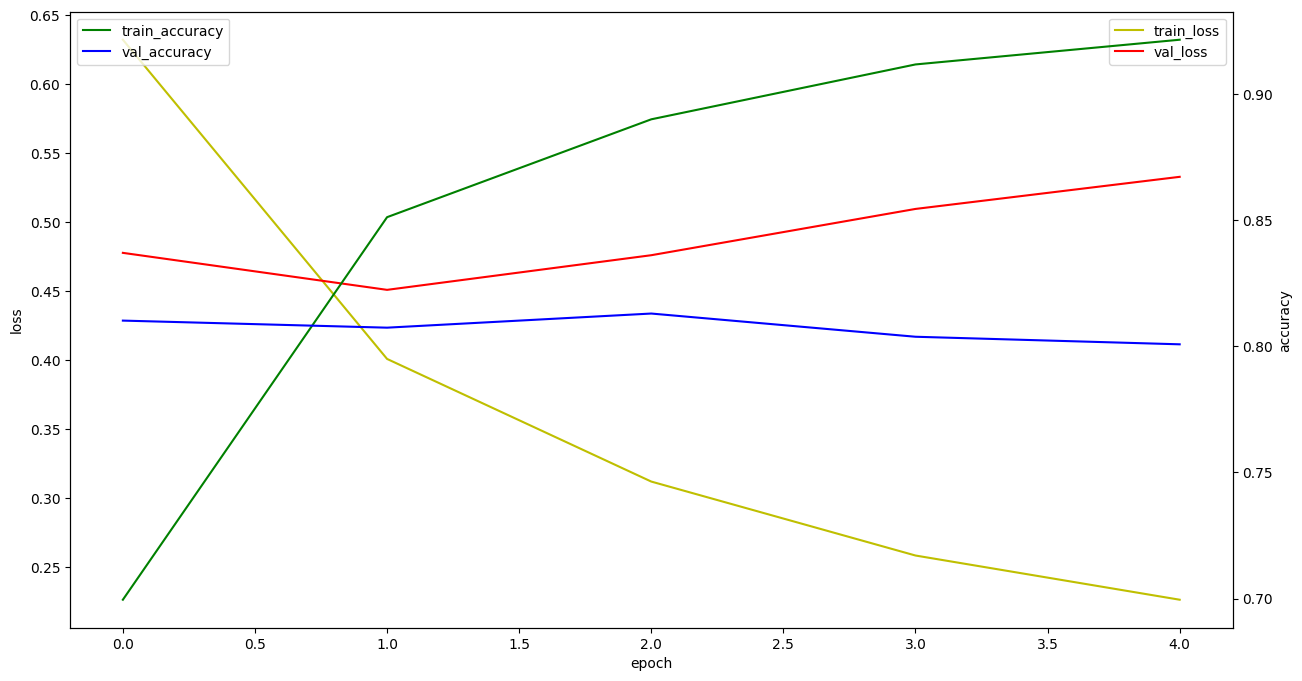

In [30]:
import matplotlib.pyplot as plt
# 학습과정살펴보기 (시각화)
fig, loss_ax=plt.subplots(figsize=(15,8))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['acc'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_acc'],'b',label='val_accuracy')

loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend()
acc_ax.legend()
plt.show()


In [31]:
loss, acc = model.evaluate(X_test, y_test, 
                           batch_size=MY_BATCH #batch_size 기본값이 32
                          )
print('test데이터의 정확도:',acc)

125/125 [==============================] - 8s 65ms/step - loss: 0.4834 - acc: 0.7942
test데이터의 정확도: 0.7942000031471252


In [34]:
# 혼동행령, recall_score, precision_score, f1_score 계산을 위한 예측값
pred = model.predict(X_test,batch_size=MY_BATCH)
y_hat= pred.argmax(axis=-1)
y_hat

125/125 [==============================] - 8s 67ms/step


array([0, 1, 1, ..., 0, 0, 1], dtype=int64)

In [35]:
confusion_matrix(y_test,y_hat)

array([[ 9404,  3096],
       [ 2049, 10451]], dtype=int64)

In [38]:
pd.crosstab(y_test,y_hat)

col_0,0,1
row_0,,
0,9404,3096
1,2049,10451


In [39]:
print('recall:', recall_score(y_test,y_hat))
print('precision:', precision_score(y_test,y_hat))
print('f1-score:', f1_score(y_test,y_hat))
print('acc : ',acc)

recall: 0.83608
precision: 0.7714623163800103
f1-score: 0.8024724536414943
acc :  0.7942000031471252


# 12. 모델 사용하기

In [53]:
review = '''It was a heavy topic, but it didn’t miss the fun along the way. 
It seems that actress Lee Jung-eun will undoubtedly have no choice but to win an award for this film.
Tonight I want to go eat malatang with my little daughter It feels light, 
yet it is dense and weighty It really makes me think of my mom while watching it, 
and it’s a movie I want to watch with my family and talk about. 
How long has it been since I last saw a movie like this?@@'''.lower()

In [54]:
import re
review=re.sub('[^a-zA-Z\s]',' ',review).split()

In [55]:
review_num=[1] + [word_to_id.get(word, -1)+3 for word in review]
review_num=[num if (num>40) & (num<10000) else 2 for num in review_num]  #10000초과시 2
print(review_num)

[2, 2, 2, 2, 1185, 2989, 2, 2, 2, 830, 717, 2, 253, 367, 2, 96, 2, 186, 2, 524, 848, 2, 2, 80, 4064, 2, 57, 1099, 2, 2, 1176, 2, 1344, 2, 2, 2, 4487, 2, 181, 2, 140, 1900, 2, 2, 61, 117, 577, 2, 764, 641, 246, 2, 2, 9545, 2, 2, 2, 66, 166, 72, 104, 2, 61, 1633, 137, 149, 2, 2, 2, 590, 2, 2, 2, 181, 2, 106, 2, 61, 223, 2, 740, 44, 89, 196, 47, 2, 77, 237, 2, 236, 219, 2, 2, 2, 2]


In [56]:
input_data= pad_sequences([review_num], 
                maxlen = MY_LENGTH,
                truncating='post', 
                padding='pre' 
                )
input_data.shape

(1, 80)

In [60]:
model.predict(input_data).argmax(axis=-1)

1/1 [==============================] - 0s 21ms/step


array([0], dtype=int64)